### **1. Imports and Reproducibility**

In [ ]:
import os
import json
import math
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
import albumentations as A
from sklearn.metrics import confusion_matrix

%matplotlib inline

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)
print("Global random seeds set to 42 for strict reproducibility.")
print("TensorFlow version:", tf.__version__)

Global random seeds set to 42 for strict reproducibility.
TensorFlow version: 2.10.0


### **2. Configuration and Paths**

In [76]:
# Setup Paths (Update these if your folder structure is different)
DATA_DIR = "RMDS_segmentation_dataset_ADE20K_350"  # Ensure this points to your dataset folder
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train")
TRAIN_ANN_FILE = os.path.join(DATA_DIR, "instances_train.json")
VAL_IMG_DIR = os.path.join(DATA_DIR, "val")
VAL_ANN_FILE = os.path.join(DATA_DIR, "instances_val.json")
TEST_IMG_DIR = os.path.join(DATA_DIR, "test")

# Global Configuration
CONFIG = {
    "img_size": 128,
    "batch_size": 16,
    "epochs": 40,
    "learning_rate": 1e-3,
    "classes": ["background", "person", "car", "book", "airplane"],
    "num_classes": 5
}

# Visualization Mapping
CLASS_COLORS = {
    "background": (0, 0, 0, 0),  
    "person": (1.0, 0.0, 0.0, 1.0),    # Red
    "car": (0.0, 1.0, 0.0, 1.0),       # Green
    "book": (1.0, 1.0, 0.0, 1.0),      # Yellow
    "airplane": (0.0, 0.0, 1.0, 1.0),  # Blue
}
CMAP = mcolors.ListedColormap([CLASS_COLORS[c] for c in CONFIG["classes"]])
NORM = mcolors.BoundaryNorm(np.arange(-0.5, CONFIG["num_classes"] + 0.5, 1), CMAP.N)

### **3. Custom Metrics (IoU & Dice)**

In [77]:
class MeanIoUMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='mean_iou', **kwargs):
        super(MeanIoUMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total_cm = self.add_weight(name='total_cm', shape=(num_classes, num_classes), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # GRAPH-SAFE FIX: Dynamically reshape y_true to match (batch, height, width)
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        cm = tf.math.confusion_matrix(tf.reshape(y_true, [-1]), tf.reshape(y_pred, [-1]), 
                                      num_classes=self.num_classes, dtype=tf.float32)
        self.total_cm.assign_add(cm)

    def result(self):
        sum_over_row = tf.reduce_sum(self.total_cm, axis=0)
        sum_over_col = tf.reduce_sum(self.total_cm, axis=1)
        true_positives = tf.linalg.diag_part(self.total_cm)
        denominator = sum_over_row + sum_over_col - true_positives
        iou = tf.math.divide_no_nan(true_positives, denominator)
        return tf.reduce_mean(iou[1:]) # Ignore background

    def reset_state(self):
        self.total_cm.assign(tf.zeros((self.num_classes, self.num_classes)))

class MeanDiceMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='mean_dice', **kwargs):
        super(MeanDiceMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.intersection = self.add_weight(name='intersection', shape=(num_classes,), initializer='zeros')
        self.cardinality = self.add_weight(name='cardinality', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # GRAPH-SAFE FIX: Dynamically reshape y_true to match (batch, height, width)
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        y_true_onehot = tf.one_hot(y_true, self.num_classes)
        y_pred_onehot = tf.one_hot(y_pred, self.num_classes)

        self.intersection.assign_add(tf.reduce_sum(y_true_onehot * y_pred_onehot, axis=[0, 1, 2]))
        self.cardinality.assign_add(tf.reduce_sum(y_true_onehot + y_pred_onehot, axis=[0, 1, 2]))

    def result(self):
        dice = tf.math.divide_no_nan(2.0 * self.intersection, self.cardinality)
        return tf.reduce_mean(dice[1:]) # Ignore background

    def reset_state(self):
        self.intersection.assign(tf.zeros((self.num_classes,)))
        self.cardinality.assign(tf.zeros((self.num_classes,)))

### **4. Loss Functions**

In [78]:
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def focal_loss_fn(y_true, y_pred):
        # GRAPH-SAFE FIX: Dynamically reshape y_true to match (batch, height, width)
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
        
        y_true_onehot = tf.one_hot(y_true, depth=len(alpha))
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        
        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = tf.gather(alpha, y_true)
        focal_term = tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(weight * tf.reduce_sum(focal_term * cross_entropy, axis=-1))
    return focal_loss_fn

def foreground_dice_loss(num_classes):
    def dice_loss_fn(y_true, y_pred):
        # GRAPH-SAFE FIX: Dynamically reshape y_true to match (batch, height, width)
        y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)[:-1]), tf.int32)
            
        y_true_onehot = tf.one_hot(y_true, depth=num_classes)
        y_true_fg = y_true_onehot[:, :, :, 1:]
        y_pred_fg = y_pred[:, :, :, 1:]
        
        intersection = tf.reduce_sum(y_true_fg * y_pred_fg, axis=[1, 2])
        union = tf.reduce_sum(y_true_fg + y_pred_fg, axis=[1, 2])
        dice_scores = tf.math.divide_no_nan(2.0 * intersection, union + K.epsilon())
        return 1.0 - tf.reduce_mean(dice_scores)
    return dice_loss_fn

def combined_focal_dice_loss(alpha, gamma=2.0, focal_weight=0.5, dice_weight=1.5):
    focal_fn = categorical_focal_loss(alpha, gamma)
    dice_fn = foreground_dice_loss(len(alpha))
    def loss_fn(y_true, y_pred):
        return focal_weight * focal_fn(y_true, y_pred) + dice_weight * dice_fn(y_true, y_pred)
    return loss_fn

### **5. Advanced Data Augmentation**

In [79]:
# Augmentation pipeline using albumentations
train_transform = A.Compose([
    A.RandomResizedCrop(size=(CONFIG["img_size"], CONFIG["img_size"]), scale=(0.4, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
])

val_transform = A.Compose([
    A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"], p=1.0)
])

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### **6. Data Loading & Generator**

In [80]:
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)
categories = coco_train.loadCats(coco_train.getCatIds())

def get_category_name(cat_id, cats):
    for cat in cats:
        if cat['id'] == cat_id: return cat['name']
    return None

class SegmentationGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_dir, coco, img_ids, batch_size, is_training=False):
        self.img_dir = img_dir
        self.coco = coco
        self.img_ids = img_ids
        self.batch_size = batch_size
        self.is_training = is_training
        self.indexes = np.arange(len(self.img_ids))
        
        # NEW: Pre-cache masks to save massive CPU time during training
        self.cached_masks = {}
        for img_id in self.img_ids:
            img_info = self.coco.loadImgs(img_id)[0]
            raw_mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
            ann_ids = self.coco.getAnnIds(imgIds=img_info['id'])
            anns = self.coco.loadAnns(ann_ids)
            for ann in anns:
                cat_name = get_category_name(ann['category_id'], categories)
                if cat_name in CONFIG["classes"]:
                    class_idx = CONFIG["classes"].index(cat_name)
                    pixel_mask = self.coco.annToMask(ann)
                    raw_mask[pixel_mask > 0] = class_idx
            self.cached_masks[img_id] = raw_mask

        if self.is_training: np.random.shuffle(self.indexes)

    def __len__(self):
        return math.ceil(len(self.img_ids) / self.batch_size)

    def on_epoch_end(self):
        if self.is_training: np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_ids = [self.img_ids[k] for k in batch_indexes]
        
        X = np.empty((len(batch_ids), CONFIG["img_size"], CONFIG["img_size"], 3), dtype=np.float32)
        Y = np.empty((len(batch_ids), CONFIG["img_size"], CONFIG["img_size"], 1), dtype=np.int32)

        for i, img_id in enumerate(batch_ids):
            img_info = self.coco.loadImgs(img_id)[0]
            img_path = os.path.join(self.img_dir, img_info['file_name'])
            raw_image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            
            # NEW: Retrieve pre-built mask from RAM instantly
            raw_mask = self.cached_masks[img_id]

            if self.is_training:
                augmented = train_transform(image=raw_image, mask=raw_mask)
            else:
                augmented = val_transform(image=raw_image, mask=raw_mask)

            X[i,] = augmented['image'] / 255.0
            Y[i,] = np.expand_dims(augmented['mask'], axis=-1)

        return X, Y

# Initialize Generators
train_ids = coco_train.getImgIds()
val_ids = coco_val.getImgIds()
train_gen = SegmentationGenerator(TRAIN_IMG_DIR, coco_train, train_ids, CONFIG["batch_size"], is_training=True)
val_gen = SegmentationGenerator(VAL_IMG_DIR, coco_val, val_ids, CONFIG["batch_size"], is_training=False)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


### **7. EDA (Histograms & Pixel Distributions)**

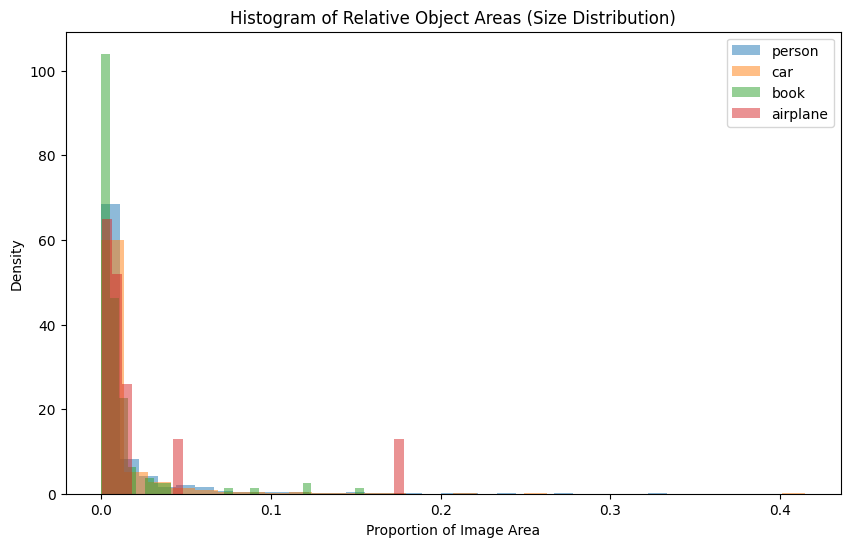

In [81]:
# EDA: Object Areas Histogram
target_classes = CONFIG["classes"][1:]
object_areas = {c: [] for c in target_classes}

for img_id in train_ids:
    img = coco_train.loadImgs(img_id)[0]
    ann_ids = coco_train.getAnnIds(imgIds=img["id"])
    annotations = coco_train.loadAnns(ann_ids)
    for ann in annotations:
        cat_name = get_category_name(ann["category_id"], categories)
        if cat_name in target_classes:
            rel_area = ann["area"] / (img["height"] * img["width"])
            object_areas[cat_name].append(rel_area)

plt.figure(figsize=(10, 6))
for cat_name in target_classes:
    if object_areas[cat_name]:
        plt.hist(object_areas[cat_name], bins=30, alpha=0.5, label=cat_name, density=True)
plt.title("Histogram of Relative Object Areas (Size Distribution)")
plt.xlabel("Proportion of Image Area")
plt.ylabel("Density")
plt.legend()
plt.show()

### **8. Custom U-Net Architecture**

In [82]:
# Updated to Industry Standard: Conv2D(no bias) -> BatchNorm -> ReLU -> Dropout
def conv_block(inputs, filters, dropout_rate=0.0):
    # use_bias=False because BatchNorm cancels out biases anyway
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
        
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(c1)
    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(c2)
    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D(2)(c3)
    c4 = conv_block(p3, 256, dropout_rate=0.3) # Added Dropout to prevent overfitting
    p4 = layers.MaxPooling2D(2)(c4)
    
    b = conv_block(p4, 512, dropout_rate=0.3)  # Added Dropout to the Bridge
    
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(b)
    u4 = layers.concatenate([u4, c4])
    c5 = conv_block(u4, 256)
    
    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c5)
    u3 = layers.concatenate([u3, c3])
    c6 = conv_block(u3, 128)
    
    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c6)
    u2 = layers.concatenate([u2, c2])
    c7 = conv_block(u2, 64)
    
    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(c7)
    u1 = layers.concatenate([u1, c1])
    c8 = conv_block(u1, 32)
    
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c8)
    return models.Model(inputs, outputs, name="Custom_UNet")

### **9. Compilation & Callbacks**

In [83]:
# Generate Aggressive Class Weights to handle imbalance
class_weights_array = np.array([0.01, 20.0, 15.0, 45.0, 50.0], dtype=np.float32)
print("Aggressive Class Weights:", dict(zip(CONFIG["classes"], class_weights_array)))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss=combined_focal_dice_loss(alpha=class_weights_array, gamma=2.0, focal_weight=0.5, dice_weight=1.5),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        MeanIoUMetric(num_classes=CONFIG["num_classes"]),
        MeanDiceMetric(num_classes=CONFIG["num_classes"])
    ],
)

# DATA SCIENCE FIX: Switch to monitoring 'val_loss' and increase patience
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',       # Changed from val_mean_iou
        mode='min',               # Loss needs to go down, not up
        patience=15,              # Increased patience to 15 epochs
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',       # Changed from val_mean_iou
        mode='min', 
        factor=0.5, 
        patience=6,               # Wait longer before dropping the learning rate
        verbose=1, 
        min_lr=1e-6
    )
]

Aggressive Class Weights: {'background': 0.01, 'person': 20.0, 'car': 15.0, 'book': 45.0, 'airplane': 50.0}


### **10. Training Custom Model**

In [84]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
)

Epoch 1/40
22/22 [==============================] - 10s 361ms/step - loss: 1.7155 - accuracy: 0.1347 - mean_iou: 0.0420 - mean_dice: 0.0783 - val_loss: 1.7851 - val_accuracy: 0.0469 - val_mean_iou: 0.0291 - val_mean_dice: 0.0555 - lr: 0.0010
Epoch 2/40
22/22 [==============================] - 7s 305ms/step - loss: 1.7058 - accuracy: 0.1522 - mean_iou: 0.0434 - mean_dice: 0.0807 - val_loss: 2.0542 - val_accuracy: 0.0642 - val_mean_iou: 0.0364 - val_mean_dice: 0.0681 - lr: 0.0010
Epoch 3/40
22/22 [==============================] - 6s 281ms/step - loss: 1.7023 - accuracy: 0.1329 - mean_iou: 0.0417 - mean_dice: 0.0775 - val_loss: 2.2166 - val_accuracy: 0.0554 - val_mean_iou: 0.0262 - val_mean_dice: 0.0501 - lr: 0.0010
Epoch 4/40
22/22 [==============================] - 6s 278ms/step - loss: 1.6483 - accuracy: 0.1221 - mean_iou: 0.0440 - mean_dice: 0.0820 - val_loss: 1.8059 - val_accuracy: 0.0917 - val_mean_iou: 0.0314 - val_mean_dice: 0.0595 - lr: 0.0010
Epoch 5/40
22/22 [=================

### **11. Training Analytics**

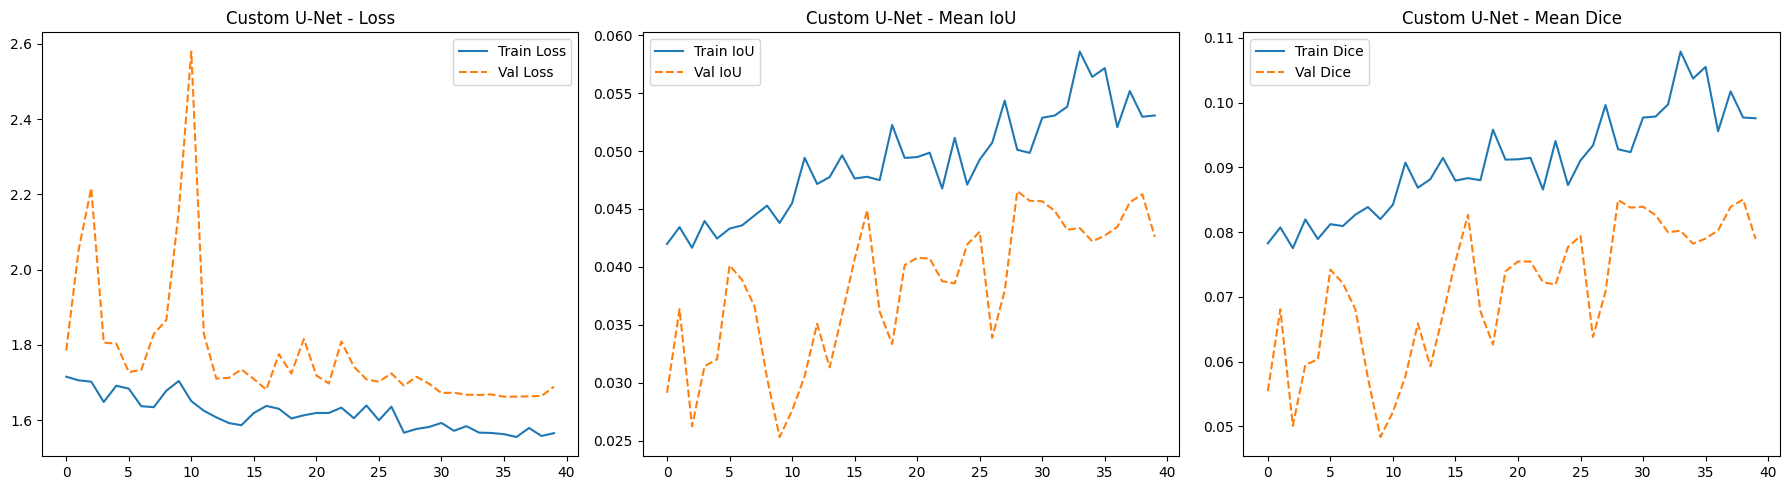

In [85]:
def plot_training_history(history_obj, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history_obj.history['loss'], label='Train Loss')
    axes[0].plot(history_obj.history['val_loss'], label='Val Loss', linestyle='--')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    
    axes[1].plot(history_obj.history['mean_iou'], label='Train IoU')
    axes[1].plot(history_obj.history['val_mean_iou'], label='Val IoU', linestyle='--')
    axes[1].set_title(f'{model_name} - Mean IoU')
    axes[1].legend()
    
    axes[2].plot(history_obj.history['mean_dice'], label='Train Dice')
    axes[2].plot(history_obj.history['val_mean_dice'], label='Val Dice', linestyle='--')
    axes[2].set_title(f'{model_name} - Mean Dice')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history, "Custom U-Net")

### **12. Pre-Trained MobileNetV2 Architecture**

In [86]:
def build_pretrained_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: (img * 2.0) - 1.0)(inputs) # MobileNet preprocessing
    
    base_model = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base_model.trainable = False 
    
    s1 = inputs                                              
    s2 = base_model.get_layer('block_1_expand_relu').output  
    s3 = base_model.get_layer('block_3_expand_relu').output  
    s4 = base_model.get_layer('block_6_expand_relu').output  
    b1 = base_model.get_layer('block_13_expand_relu').output 
    
    u4 = layers.Conv2DTranspose(192, 2, strides=2, padding="same")(b1)
    u4 = layers.concatenate([u4, s4])
    c4 = conv_block(u4, 192)
    
    u3 = layers.Conv2DTranspose(144, 2, strides=2, padding="same")(c4)
    u3 = layers.concatenate([u3, s3])
    c3 = conv_block(u3, 144)
    
    u2 = layers.Conv2DTranspose(96, 2, strides=2, padding="same")(c3)
    u2 = layers.concatenate([u2, s2])
    c2 = conv_block(u2, 96)
    
    u1 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c2)
    u1 = layers.concatenate([u1, s1])
    c1 = conv_block(u1, 64)
    
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c1)
    return models.Model(inputs, outputs, name="Pretrained_MobileNetV2_UNet")

pretrained_model = build_pretrained_unet((CONFIG["img_size"], CONFIG["img_size"], 3), CONFIG["num_classes"])
pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss=combined_focal_dice_loss(alpha=class_weights_array, gamma=2.0, focal_weight=0.5, dice_weight=1.5),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"), MeanIoUMetric(num_classes=CONFIG["num_classes"]), MeanDiceMetric(num_classes=CONFIG["num_classes"])],
)

### **13. Training Pre-Trained Model**

Epoch 1/40
22/22 [==============================] - 13s 452ms/step - loss: 1.9789 - accuracy: 0.1557 - mean_iou: 0.0368 - mean_dice: 0.0684 - val_loss: 5.2382 - val_accuracy: 0.0477 - val_mean_iou: 0.0121 - val_mean_dice: 0.0231 - lr: 0.0010
Epoch 2/40
22/22 [==============================] - 8s 361ms/step - loss: 1.6620 - accuracy: 0.2114 - mean_iou: 0.0508 - mean_dice: 0.0923 - val_loss: 2.5292 - val_accuracy: 0.0948 - val_mean_iou: 0.0270 - val_mean_dice: 0.0514 - lr: 0.0010
Epoch 3/40
22/22 [==============================] - 8s 343ms/step - loss: 1.6305 - accuracy: 0.2037 - mean_iou: 0.0521 - mean_dice: 0.0941 - val_loss: 1.8306 - val_accuracy: 0.0601 - val_mean_iou: 0.0552 - val_mean_dice: 0.0962 - lr: 0.0010
Epoch 4/40
22/22 [==============================] - 8s 342ms/step - loss: 1.5919 - accuracy: 0.2241 - mean_iou: 0.0558 - mean_dice: 0.1013 - val_loss: 4.3718 - val_accuracy: 0.0470 - val_mean_iou: 0.0688 - val_mean_dice: 0.1193 - lr: 0.0010
Epoch 5/40
22/22 [=================

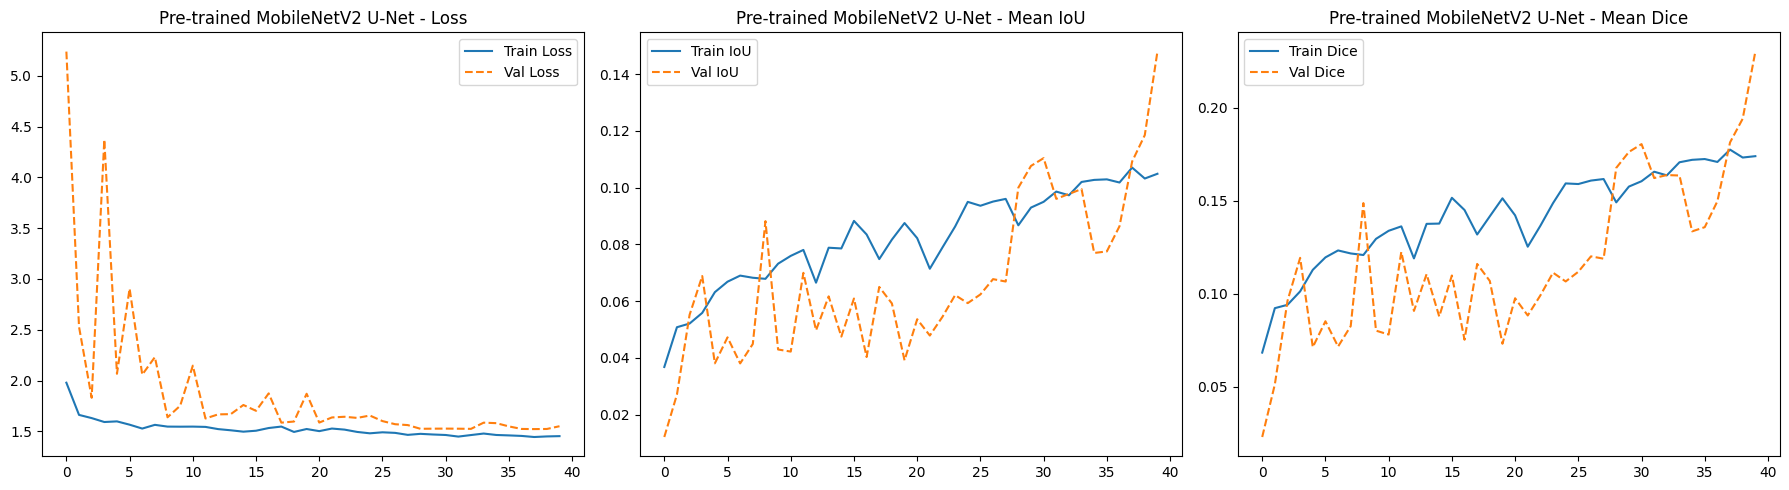

In [87]:
history_pretrained = pretrained_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
)
plot_training_history(history_pretrained, "Pre-trained MobileNetV2 U-Net")

### **14. Per-Class Evaluation Metrics**

In [88]:
def compute_per_class_iou(eval_model, generator, num_classes):
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    for i in range(len(generator)):
        x, y = generator[i]
        preds = np.argmax(eval_model.predict(x, verbose=0), axis=-1)
        
        # Accumulate the confusion matrix batch-by-batch to save RAM
        total_cm += confusion_matrix(y.flatten(), preds.flatten(), labels=list(range(num_classes)))
    
    # Calculate IoU directly from the accumulated matrix
    ious = [(total_cm[c, c] / (total_cm[:, c].sum() + total_cm[c, :].sum() - total_cm[c, c] + 1e-7)) for c in range(num_classes)]
    return ious

custom_ious = compute_per_class_iou(model, val_gen, CONFIG["num_classes"])
pt_ious = compute_per_class_iou(pretrained_model, val_gen, CONFIG["num_classes"])

print("--- Per-Class IoU Breakdown (Validation Set) ---")
for i, class_name in enumerate(CONFIG["classes"]):
    print(f" - {class_name.ljust(12)} | Custom U-Net: {custom_ious[i]:.4f} | MobileNetV2: {pt_ious[i]:.4f}")

--- Per-Class IoU Breakdown (Validation Set) ---
 - background   | Custom U-Net: 0.0883 | MobileNetV2: 0.2480
 - person       | Custom U-Net: 0.0694 | MobileNetV2: 0.2423
 - car          | Custom U-Net: 0.0930 | MobileNetV2: 0.3355
 - book         | Custom U-Net: 0.0061 | MobileNetV2: 0.0081
 - airplane     | Custom U-Net: 0.0018 | MobileNetV2: 0.0060


### **15. Side-by-Side Visual Evaluation**

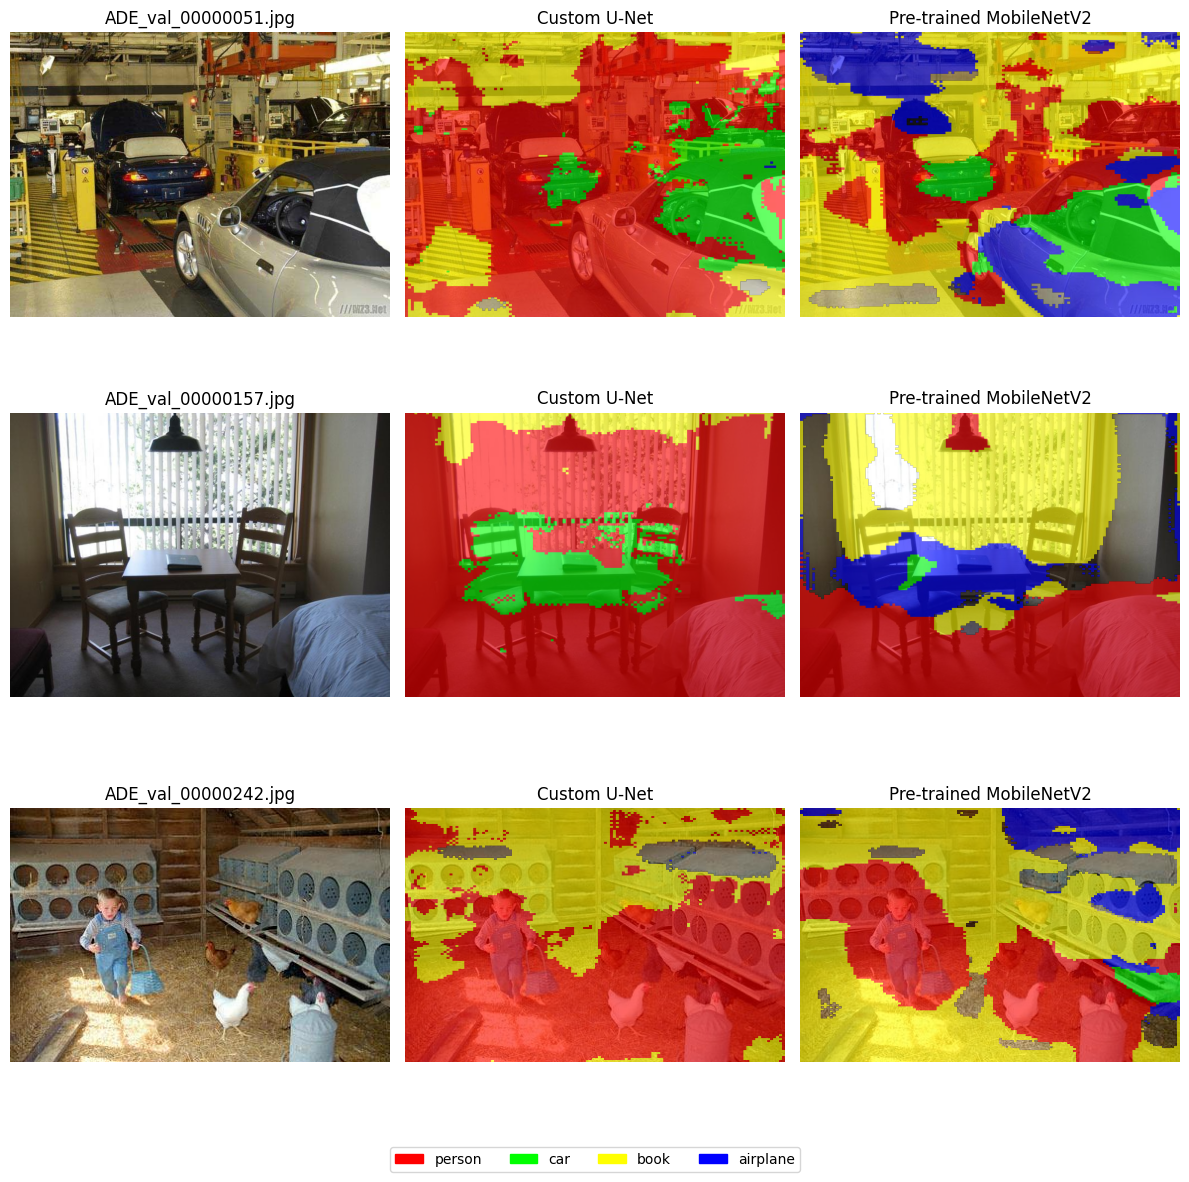

In [89]:
test_image_paths = glob.glob(os.path.join(TEST_IMG_DIR, "*.jpg"))[:3]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, path in enumerate(test_image_paths):
    raw = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    resized = cv2.resize(raw, (CONFIG["img_size"], CONFIG["img_size"])) / 255.0
    img_tensor = np.expand_dims(resized, axis=0)

    pred_custom = np.argmax(model.predict(img_tensor, verbose=0)[0], axis=-1)
    pred_full_custom = cv2.resize(pred_custom.astype(np.uint8), (raw.shape[1], raw.shape[0]), interpolation=cv2.INTER_NEAREST)

    pred_pt = np.argmax(pretrained_model.predict(img_tensor, verbose=0)[0], axis=-1)
    pred_full_pt = cv2.resize(pred_pt.astype(np.uint8), (raw.shape[1], raw.shape[0]), interpolation=cv2.INTER_NEAREST)

    axes[i, 0].imshow(raw)
    axes[i, 0].set_title(os.path.basename(path))
    axes[i, 0].axis("off")

    axes[i, 1].imshow(raw)
    axes[i, 1].imshow(pred_full_custom, cmap=CMAP, norm=NORM, alpha=0.6)
    axes[i, 1].set_title("Custom U-Net")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(raw)
    axes[i, 2].imshow(pred_full_pt, cmap=CMAP, norm=NORM, alpha=0.6)
    axes[i, 2].set_title("Pre-trained MobileNetV2")
    axes[i, 2].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in CONFIG["classes"][1:]]
fig.legend(handles, CONFIG["classes"][1:], loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()